# Genz Function in Dakota and QMCPy

Original QMCPy demo: [`QMCPy/demos/DAKOTA_Genz/dakota_genz.ipynb`](../../../QMCPy/demos/DAKOTA_Genz/dakota_genz.ipynb)

The original Python notebook performs a broad comparison that includes Dakota point sets. This Julia translation focuses on the overlapping `QMC.jl` samplers and the same Genz benchmark families.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QMC.jl/blob/develop/demos/DAKOTA_Genz/dakota_genz.ipynb)

Parity note: QMCPy's original notebook runs a broader multi-dimension Dakota comparison with external Halton data. This Julia notebook keeps the overlapping Genz benchmark idea by comparing `IIDStdUniform`, `Lattice`, and `DigitalNetB2` on the `d=4` `:oscillatory` and `:corner_peak` cases at `abs_tol=5e-3`, using a high-accuracy natural-order digital-net solve as the reference and omitting the Dakota-specific point-set section.


In [1]:
using QMC
using Printf

const HAVE_PLOTS = Base.find_package("Plots") !== nothing
HAVE_PLOTS && @eval using Plots
if HAVE_PLOTS
    Plots.default(
        titlefont=Plots.font(9),
        plot_titlefont=Plots.font(11),
        left_margin=4Plots.mm,
        right_margin=8Plots.mm,
        top_margin=8Plots.mm,
        bottom_margin=5Plots.mm,
    )
end


**Benchmark setup.**

We compare `IIDStdUniform`, `Lattice`, and `DigitalNetB2` on two standard Genz test functions. A high-accuracy digital-net solve serves as the reference value.


In [2]:
d = 4
a = ones(d)
u = 0.5 .* ones(d)
kinds = [:oscillatory, :corner_peak]

function reference_solution(kind)
    dd = DigitalNetB2(d; seed=17, graycode=false)
    f = Genz(Uniform(dd); kind=kind, a=a, u=u)
    return integrate(CubQMCNetG(f; abs_tol=1e-8)).solution
end

function estimate_with_sampler(kind, sampler_name)
    if sampler_name == :IID
        dd = IIDStdUniform(d; seed=7)
        f = Genz(Uniform(dd); kind=kind, a=a, u=u)
        return integrate(CubMCG(f; abs_tol=5e-3)).solution
    elseif sampler_name == :Lattice
        dd = Lattice(d; seed=7)
        f = Genz(Uniform(dd); kind=kind, a=a, u=u)
        return integrate(CubQMCLatticeG(f; abs_tol=5e-3)).solution
    elseif sampler_name == :DigitalNetB2
        dd = DigitalNetB2(d; seed=7, graycode=false)
        f = Genz(Uniform(dd); kind=kind, a=a, u=u)
        return integrate(CubQMCNetG(f; abs_tol=5e-3)).solution
    else
        error("unknown sampler")
    end
end


estimate_with_sampler (generic function with 1 method)

In [3]:
rows = NamedTuple[]
for kind in kinds
    ref = reference_solution(kind)
    for sampler in (:IID, :Lattice, :DigitalNetB2)
        est = estimate_with_sampler(kind, sampler)
        push!(rows, (kind=kind, sampler=sampler, reference=ref, estimate=est, abs_error=abs(est - ref)))
    end
end

@printf("  %-14s  %-13s  %10s  %10s  %10s\n", "kind", "sampler", "reference", "estimate", "abs_error")
println("  " * repeat("─", 65))
for r in rows
    @printf("  %-14s  %-13s  %10.4f  %10.4f  %10.2e\n",
        r.kind, r.sampler, r.reference, r.estimate, r.abs_error)
end

@assert maximum(row.abs_error for row in rows if row.sampler != :IID) < 2e-3

  kind            sampler         reference    estimate   abs_error
  ─────────────────────────────────────────────────────────────────


  oscillatory     IID                0.3518      0.3523    5.45e-04


  oscillatory     Lattice            0.3518      0.3502    1.55e-03
  oscillatory     DigitalNetB2       0.3518      0.3510    7.15e-04
  corner_peak     IID                0.0083      0.0083    8.09e-05
  corner_peak     Lattice            0.0083      0.0081    1.89e-04
  corner_peak     DigitalNetB2       0.0083      0.0082    1.51e-04


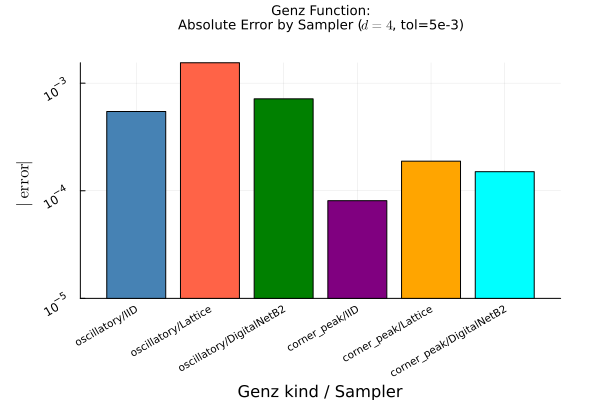

In [4]:
if HAVE_PLOTS
    err_vals = [abs(r.abs_error) for r in rows]
    labels   = ["$(r.kind)/$(r.sampler)" for r in rows]
    colors   = [:steelblue, :tomato, :green, :purple, :orange, :cyan]

    p = bar(labels, err_vals;
        color=colors[1:length(labels)],
        yscale=:log10, rotation=30,
        xlabel="Genz kind / Sampler", ylabel="\$|\\mathrm{error}|\$",
        title="Genz Function:\nAbsolute Error by Sampler (\$d=$d\$, tol=5e-3)",
        legend=false, xtickfontsize=7)
    display(p)
end


The digital-net solver requires natural order in `QMC.jl`, so the notebook constructs `DigitalNetB2(...; graycode=false)` for the `CubQMCNetG` runs.
